# Final Analysis for 1mio events

### Data
1. low min_thresh=-0.002 for sig and bkg saved under all*lowthresh.npy
2. jitter deltas saved under all_deltas.npy with min_thresh=-0.02

### Tasks:
1. rewriting older functions for loop compatibility
2. loop over the 200 or so acquisitions inside of the directory
3. save metadata inside of the histograms and add up $\rightarrow$ decide for binning based on signal file? on first? or select maximum from all of them? binning isn't really adaptable if I want to save in array

In [82]:
import pandas as pd
import numpy as np
import scipy as sp
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import csv
import pyarrow as pa 
import RS_RTxReadBin as rb  
from RS_RTxReadBin.RTxReadBin import RTxReadBin  
import os 
from scipy.optimize import curve_fit
from pathlib import Path
import time

In [53]:
import functions_singledata as my_fcts
import importlib

In [80]:
importlib.reload(my_fcts)

<module 'functions_singledata' from '/Users/laloscola/Library/Mobile Documents/com~apple~CloudDocs/Arbeit/Max-Planck/magic coding new /code_for_MCPPMT_Camera/functions_singledata.py'>

## Visual analysis of Peaks for the two Measurements (bkg and sig)

visual analysis tells me the peak range is (-0.35e-8, -0.1e-8) $\rightarrow$ is it the same for all files? $\Rightarrow$ seems that way

### writing new function that selects the range to integrate over

In [72]:
df_fixed = my_fcts.converter_binary_to_df('/Users/laloscola/ExternalDrive/1mio_events_sig/Run_000.Wfm.bin')

Found multichannel File, with channels: 1, 2. Using these!


Resolution -> 1e-12
RecordLength -> 20000.0
Number of Acquisitions: 5000
Timestamps recorded: Yes
Number of channels given: 2


The mean area is: 1.3211746667011788e-12 Vs


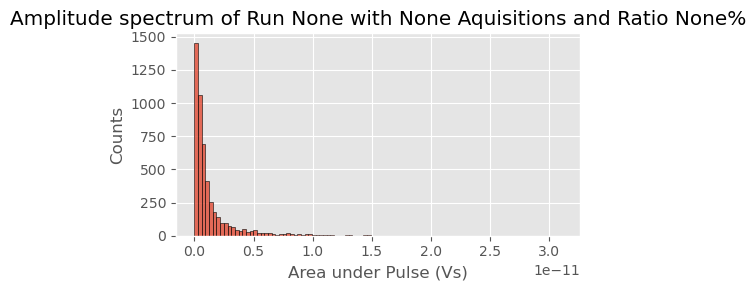

[np.float64(5.601253710192394e-13),
 np.float64(1.4725049386784125e-12),
 np.float64(4.2916255059139887e-13),
 np.float64(6.480051921535041e-13),
 np.float64(1.207170209448812e-13),
 np.float64(7.782361673831704e-13),
 np.float64(8.516396971779149e-13),
 np.float64(1.1829916170017868e-13),
 np.float64(3.1070497818868716e-12),
 np.float64(5.914772680429222e-13),
 np.float64(2.7318120775169025e-13),
 np.float64(9.218070631914089e-13),
 np.float64(4.548573370328772e-13),
 np.float64(2.6010776976472685e-12),
 np.float64(5.648036084982106e-13),
 np.float64(6.594460205221828e-13),
 np.float64(2.719954273115969e-13),
 np.float64(2.627933541705254e-13),
 np.float64(4.844861643134644e-13),
 np.float64(1.3095046977525695e-13),
 np.float64(1.7191823140035492e-13),
 np.float64(7.416933837953379e-14),
 np.float64(9.643558569097193e-13),
 np.float64(2.720973304138863e-13),
 np.float64(3.811728051392719e-13),
 np.float64(2.9681632853316834e-13),
 np.float64(4.90029025781494e-13),
 np.float64(6.596776

In [83]:
my_fcts.main_amplitude_spectrum(df_fixed)

## Amplitude Code

In [90]:
path_sig = Path('/Users/laloscola/ExternalDrive/1mio_events_bkg/')
files_sig = list(path_sig.glob('Run_*.Wfm.bin'))
count_sig = len(files_sig)
print(f'There are {count_sig} signal files')

There are 100 signal files


In [91]:
dx = 0.5e-12 # max resolution was 1e-12 (area can still have non-integer values) --- adapt such that selecting the number of bins autosets dx
bin_edges_jitter = np.arange(-15e-9, 15e-9 + dx, dx) # this would give 10000 bins
bin_edges_ampl = np.arange(0e-10, 2e-10 +dx, dx)

In [92]:
counts_total_jitter = np.zeros(len(bin_edges_jitter) - 1, dtype=np.int64)
counts_total_ampl = np.zeros(len(bin_edges_ampl) - 1, dtype=np.int64)

#### Code that computes counts first and makes histograms later

In [93]:
all_ampl_new = []
for file_path_sig in sorted(files_sig): # looping over first 3 files now
    print(file_path_sig)
    df = my_fcts.converter_binary_to_df(file_path_sig, show_info=False)
    # main_ratio_and_plots(df, min_thresh=-0.01, show_only_camera=False)
    values_ampl = my_fcts.main_amplitude_spectrum(df, fixed_window=True, show_plots=False,integration_range=(-0.25e-8, -0.15e-8))
    all_ampl_new.append(np.asarray(values_ampl))

all_ampl_fixed_window = np.concatenate(all_ampl_new)

Found multichannel File, with channels: 1, 2. Using these!


/Users/laloscola/ExternalDrive/1mio_events_bkg/Run_000.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


The mean area is: 4.30501108200051e-13 Vs
/Users/laloscola/ExternalDrive/1mio_events_bkg/Run_001.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


...

The mean area is: 4.2760693519938563e-13 Vs
/Users/laloscola/ExternalDrive/1mio_events_bkg/Run_097.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


The mean area is: 4.3072177151183254e-13 Vs
/Users/laloscola/ExternalDrive/1mio_events_bkg/Run_098.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


The mean area is: 4.2379702655206813e-13 Vs
/Users/laloscola/ExternalDrive/1mio_events_bkg/Run_099.Wfm.bin
The mean area is: 4.2156841177801833e-13 Vs


$\rightarrow$ saved all_ampl_sig under sig_amplitudes.npy

In [94]:
np.save('all_bkg_ampl_fixed_window.npy', all_ampl_fixed_window)

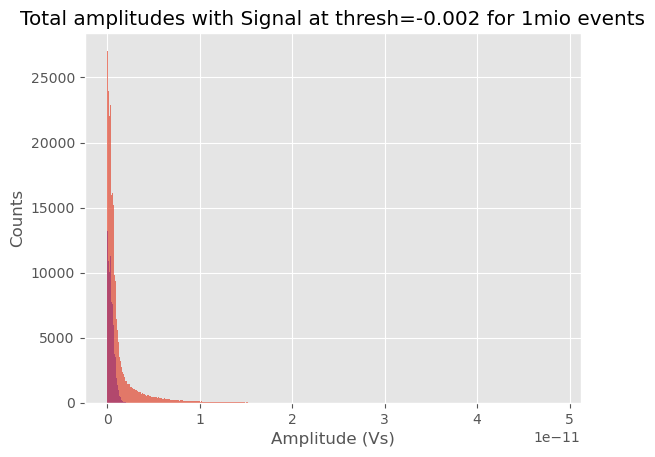

In [101]:
bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

all_sig = np.load('all_sig_ampl_fixed_window.npy')
all_bkg = np.load('all_bkg_ampl_fixed_window.npy')

plt.figure()
plt.style.use('ggplot')

plt.hist(all_bkg, bins='auto', color='blue', alpha=0.7)
plt.hist(all_sig, bins='auto', alpha=0.7)
plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Total amplitudes with Signal at thresh=-0.002 for 1mio events")
plt.show()

In [60]:
S_new, edges_new = np.histogram(all_ampl_new)
centers = 0.5 * (edges_new[:-1] + edges_new[1:])
mu = np.average(centers, weights=S_new)
print(mu)

1.8448615655651536e-11


In [5]:
path_bkg = Path('/Users/laloscola/ExternalDrive/1mio_events_bkg/')
files_bkg = list(path_bkg.glob('Run_*.Wfm.bin'))
count_bkg = len(files_bkg)
print(f'There are {count_bkg} background files')

There are 100 background files


In [ ]:
all_ampl_bkg = []
for file_path_bkg in sorted(files_bkg): # looping over first 3 files now
    print(file_path_bkg)
    df = converter_binary_to_df(file_path_bkg, show_info=False)
    # main_ratio_and_plots(df, min_thresh=-0.01, show_only_camera=False)
    values_ampl = main_amplitude_spectrum(df, min_thresh=-0.002 ,show_plots=False)
    all_ampl_bkg.append(np.asarray(values_ampl))

all_ampl_bkg = np.concatenate(all_ampl_bkg)

$\rightarrow$ saved all_ampl_bkg under bkg_amplitudes.npy

In [ ]:
plt.figure()
plt.style.use('ggplot')
plt.hist(all_ampl_bkg, bins='auto', color='orange', alpha=0.7)
plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Total amplitude of the Background at thresh=-0.002 for 1mio events")
plt.show()

## Now plots and analysis (calculation done above)
-> calculated data has been saved as np.array

In [161]:
dx = 0.07e-12 # max resolution was 1e-12 (area can still have non-integer values) --- adapt such that selecting the number of bins autosets dx
bin_edges_jitter = np.arange(-15e-9, 15e-9 + dx, dx) # this would give 10000 bins
bin_edges_ampl = np.arange(0e-10, 1.5e-11 +dx, dx)

52808 69943


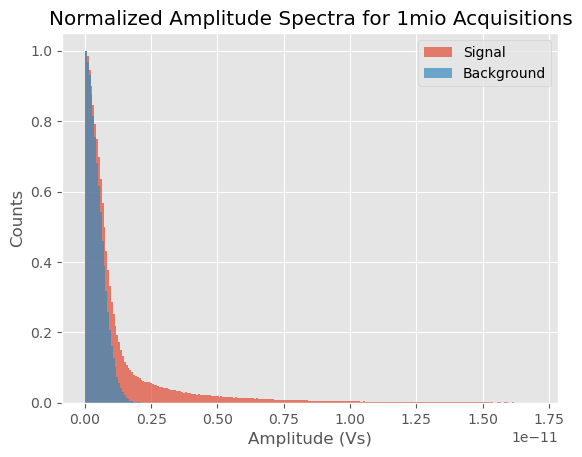

In [168]:
all_ampl_sig = np.load('all_sig_ampl_fixed_window.npy')
all_ampl_bkg = np.load('all_bkg_ampl_fixed_window.npy')

bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

S, edges_s = np.histogram(all_ampl_sig, bins=bin_edges_ampl) # looses the 1e-11
B, edges_b = np.histogram(all_ampl_bkg, bins=bin_edges_ampl)

#Ns = max(all_ampl_sig)
#Nb = max(all_ampl_bkg)
Nb = max(np.histogram(all_ampl_bkg, bins=bin_edges_ampl)[0])
Ns = max(np.histogram(all_ampl_sig, bins=bin_edges_ampl)[0]) # needed for normalisation -> S - N_S/N_B * B
print(Nb, Ns)

plt.figure()
plt.style.use('ggplot')
#plt.stairs(S/Ns, edges_s, alpha=1, label='Signal')
#plt.stairs(B/Nb, edges_b, alpha=1, label='Background')
plt.bar(bin_left, S/Ns, width=bin_width, align='edge', color='C0', alpha=0.7, label='Signal')
plt.bar(bin_left, B/Nb, width=bin_width, align='edge', color='C1', alpha=0.7, label='Background')


#plt.yscale('log')                 # <-- add this (log y-axis) [web:2]


plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.legend()
plt.title("Normalized Amplitude Spectra for 1mio Acquisitions")
# plt.savefig("amplitude_both_hist_fixed_window.png", dpi=300, bbox_inches="tight")

plt.show()

In [154]:
centers = 0.5 * (edges_s[:-1] + edges_s[1:])
mu = np.average(centers, weights=S)
print(mu)

1.2678771851731547e-12


In [163]:
dx = 0.07e-12 # max resolution was 1e-12 (area can still have non-integer values) --- adapt such that selecting the number of bins autosets dx
bin_edges_jitter = np.arange(-15e-9, 15e-9 + dx, dx) # this would give 10000 bins
bin_edges_ampl = np.arange(0, 1.7e-11 +dx, dx)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
52808 69943
only positive values in Sig - Bkg


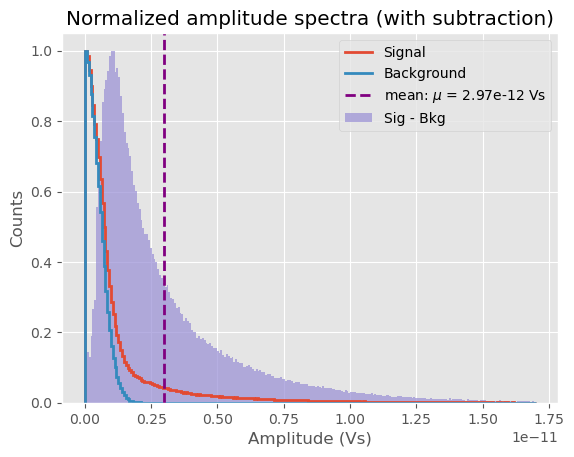

In [170]:
all_ampl_sig = np.load('all_sig_ampl_fixed_window.npy')
all_ampl_bkg = np.load('all_bkg_ampl_fixed_window.npy')

bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

plt.figure()
plt.style.use('ggplot')

S, edges = np.histogram(all_ampl_sig, bins=bin_edges_ampl) # looses the 1e-11
B, edges = np.histogram(all_ampl_bkg, bins=bin_edges_ampl)

# ------------------ calculations ---------------
Nb = max(np.histogram(all_ampl_bkg, bins=bin_edges_ampl)[0])
Ns = max(np.histogram(all_ampl_sig, bins=bin_edges_ampl)[0]) # needed for normalisation -> S - N_S/N_B * B

print(Nb, Ns)

S_sub = S/Ns - (1/Nb) * B
S_sub = S_sub/max(S_sub)

centers = 0.5 * (edges[:-1] + edges[1:])
mu = np.average(centers, weights=S_sub)

if not S_sub.any() < 0:
    print('only positive values in Sig - Bkg')


# --------------------- plots -----------------
plt.bar(bin_left, S_sub, width=bin_width, align='edge', label='Sig - Bkg', color='C2', alpha=0.7) #np.arange(0,2000,40))


plt.stairs(S/Ns, edges, label='Signal', color='C0', linewidth=2)
plt.stairs(B/Nb, edges, label='Background', color='C1', linewidth=2)
#plt.bar(bin_left, S/Ns, width=bin_width, align='edge', color='C0', alpha=0.4, label='Signal')
#plt.bar(bin_left, B/Nb, width=bin_width, align='edge', color='C1', alpha=0.4, label='Background')
plt.axvline(mu, color="purple", linestyle="--", linewidth=2,  label=fr'mean: $\mu$ = {mu:.3g} Vs')   

plt.xlabel("Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Normalized amplitude spectra (with subtraction)")
plt.legend()
# plt.savefig("amplitude_subtracted_hist_fixed_window.png", dpi=300, bbox_inches="tight")
plt.show()

final idea:
- plot S with min_thresh=-0.002
- plot B with min_thresh=-0.002
- plot S_sub as S with min_thresh=-0.01 instead of S_sub= S - k*B

### Jitter Code

In [10]:
import functions_singledata as my_fcts
import importlib

In [3]:
ds = converter_binary_to_df('/Users/laloscola/ExternalDrive/1mio_events_sig/Run_000.Wfm.bin')

Found multichannel File, with channels: 1, 2. Using these!


Resolution -> 1e-12
RecordLength -> 20000.0
Number of Acquisitions: 5000
Timestamps recorded: Yes
Number of channels given: 2


In [4]:
path_sig = Path('/Users/laloscola/ExternalDrive/1mio_events_sig/')
files_sig = list(path_sig.glob('Run_*.Wfm.bin'))
count_sig = len(files_sig)
print(f'There are {count_sig} signal files')

There are 200 signal files


In [5]:
all_deltas =  []
for file_path_sig in sorted(files_sig):
    print(file_path_sig)
    df = converter_binary_to_df(file_path_sig, show_info=False)

    deltas, mean_offset, jitter = main_jitter_plot_and_fwhm(df, min_thresh=-0.02, show_plots=False)
    print(len(deltas))
    all_deltas.append(np.asarray(deltas))
all_deltas =  np.concatenate(all_deltas)

Found multichannel File, with channels: 1, 2. Using these!


/Users/laloscola/ExternalDrive/1mio_events_sig/Run_000.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


62
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_001.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


...

85
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_197.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


79
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_198.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


82
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_199.Wfm.bin
81


In [ ]:
np.save('all_deltas.npy', all_deltas)

In [6]:
from functions_singledata import plot_jitter_histogram
from functions_singledata import plot_jitter_gaussian_two_views

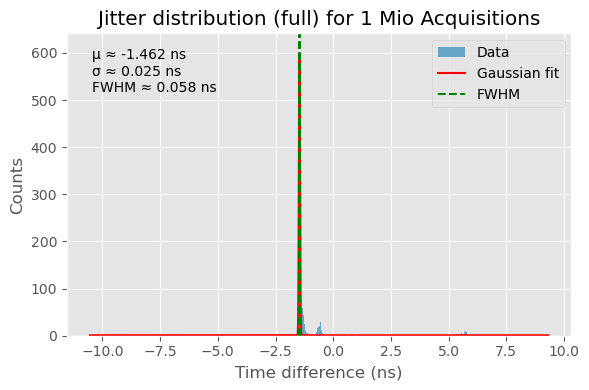

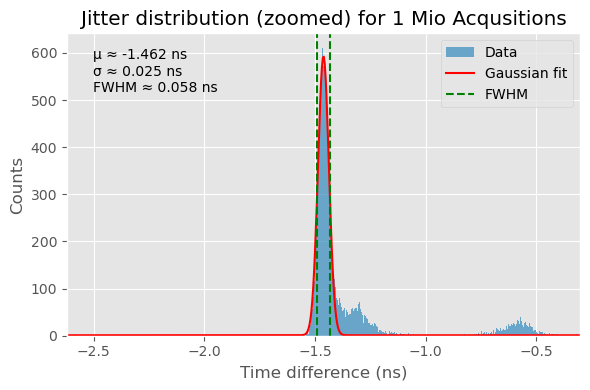

(np.float64(-1.461761283398091e-09),
 np.float64(2.4597369820078024e-11),
 np.float64(5.7922379507359044e-11))

In [171]:
importlib.reload(my_fcts)
all_deltas = np.load('all_deltas.npy')
my_fcts.plot_jitter_gaussian_two_views(all_deltas, bins=5000, save_full_fig=True, save_zoomed_fig=True, zoom_factor=40)

- Breite der Pulse berechnen 